In [1]:
import os, glob

# Verify Kaggle input is available
input_root = '/kaggle/input'
for p in sorted(glob.glob(f'{input_root}/**', recursive=False)):
    print(p)


/kaggle/input/competitions


In [2]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))


2026-05-23 19:32:07.418718: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779564727.655986      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779564727.721531      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779564728.301417      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779564728.301475      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779564728.301480      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# Kaggle input path — adjust the dataset slug to match your competition
KAGGLE_DATA_DIR = '/kaggle/input/competitions/ai-biz-2026-spring-task-3'

if not os.path.exists(KAGGLE_DATA_DIR):
    # Fallback: search for the CSV anywhere under /kaggle/input
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'fashion-mnist_train.csv' in files:
            KAGGLE_DATA_DIR = root
            break
    else:
        raise FileNotFoundError(
            'fashion-mnist_train.csv not found under /kaggle/input. '
            'Add the dataset to this notebook via "Add data".'
        )

DATA_DIR = KAGGLE_DATA_DIR
TRAIN_PATH      = os.path.join(DATA_DIR, 'fashion-mnist_train.csv')
TEST_PATH       = os.path.join(DATA_DIR, 'fashion-mnist_test.csv')
SAMPLE_SUB_PATH = os.path.join(DATA_DIR, 'fashion-mnist_test_sample_submission.csv')

train_df   = pd.read_csv(TRAIN_PATH)
test_df    = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

print('DATA_DIR:', DATA_DIR)
print('Train shape:', train_df.shape)
print('Test shape: ', test_df.shape)
print(sample_sub.head())


DATA_DIR: /kaggle/input/competitions/ai-biz-2026-spring-task-3
Train shape: (60000, 785)
Test shape:  (10000, 784)
   imageID  label
0        0      2
1        1      1
2        2      9
3        3      1
4        4      6


In [4]:
# Prepare arrays
y = train_df['label'].values.astype(np.int64)
X = train_df.drop(columns=['label']).values.astype(np.float32) / 255.0
X_test = test_df.values.astype(np.float32) / 255.0

X      = X.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Keep native 28×28 — bicubic upsampling to 56×56 only interpolates existing
# pixels and adds no real information, while forcing a much larger model and
# wasting memory/compute with no discriminative gain.
IMG_SIZE = 28

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=SEED, stratify=y
)

print(f'IMG_SIZE:  {IMG_SIZE}×{IMG_SIZE} (native resolution)')
print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val:  ', X_val.shape,   'y_val:  ', y_val.shape)
print('X_test: ', X_test.shape)


IMG_SIZE:  28×28 (native resolution)
X_train: (54000, 28, 28, 1) y_train: (54000,)
X_val:   (6000, 28, 28, 1) y_val:   (6000,)
X_test:  (10000, 28, 28, 1)


In [5]:
# Config
NUM_CLASSES  = 10
BATCH_SIZE   = 256
AUTO         = tf.data.AUTOTUNE

SEEDS        = [11, 23, 47, 59, 73]   # 5-seed ensemble for lower variance
EPOCHS_BASE  = 28
EPOCHS_SPEC  = 22
N_TTA        = 5   # test-time augmentation passes (1 clean + 4 augmented)

CONFUSION_CLASSES = [0, 2, 4, 6]   # T-shirt, Pullover, Coat, Shirt (shirt cluster)
SHIRT_CLASS   = 6

CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

def make_sparse_cce(label_smoothing=0.0):
    try:
        return keras.losses.SparseCategoricalCrossentropy(label_smoothing=label_smoothing)
    except TypeError:
        if label_smoothing > 0:
            print('label_smoothing not supported in this TF build; using 0.0')
        return keras.losses.SparseCategoricalCrossentropy()

print('Shirt-cluster confusion classes:', CONFUSION_CLASSES)


Shirt-cluster confusion classes: [0, 2, 4, 6]


In [6]:
# tf.data helpers — integer labels (SparseCCE), MixUp/flip removed

class RandomCutout(keras.layers.Layer):
    """Zero out a random patch in each image (Cutout / Random Erasing).
    Proved effective for Fashion-MNIST: forces the model to use global texture
    rather than relying on a single discriminative region."""
    def __init__(self, height=8, width=8, **kwargs):
        super().__init__(**kwargs)
        self.height = height
        self.width  = width

    def call(self, x, training=None):
        if not training:
            return x
        bsz = tf.shape(x)[0]
        ih  = tf.shape(x)[1]
        iw  = tf.shape(x)[2]
        top  = tf.random.uniform([bsz], 0, ih - self.height + 1, dtype=tf.int32)
        left = tf.random.uniform([bsz], 0, iw - self.width  + 1, dtype=tf.int32)
        r = tf.range(ih, dtype=tf.int32)[None, :, None, None]
        c = tf.range(iw, dtype=tf.int32)[None, None, :, None]
        t = top [:, None, None, None]
        l = left[:, None, None, None]
        keep = ~((r >= t) & (r < t + self.height) & (c >= l) & (c < l + self.width))
        keep = tf.cast(tf.broadcast_to(keep, tf.shape(x)), x.dtype)
        return x * keep

def make_base_train_dataset(X_arr, y_arr, seed=SEED):
    aug = keras.Sequential([
        layers.RandomTranslation(0.08, 0.08),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.08),
        RandomCutout(height=8, width=8),   # occlude 8×8 patch; improves texture use
    ], name='aug')

    ds = tf.data.Dataset.from_tensor_slices((X_arr, y_arr))
    ds = ds.shuffle(len(X_arr), seed=seed)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.map(lambda x, y: (aug(x, training=True), y), num_parallel_calls=AUTO)
    return ds.prefetch(AUTO)

def make_eval_dataset(X_arr, y_arr=None):
    if y_arr is None:
        ds = tf.data.Dataset.from_tensor_slices(X_arr)
        return ds.batch(BATCH_SIZE).prefetch(AUTO)
    ds = tf.data.Dataset.from_tensor_slices((X_arr, y_arr))
    return ds.batch(BATCH_SIZE).prefetch(AUTO)

# ── Test-Time Augmentation ──────────────────────────────────────────────────
# No Cutout during TTA — never remove information at inference time.
_tta_aug = keras.Sequential([
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.08),
], name='tta_aug')

def predict_tta(model, X_arr, n_tta=N_TTA):
    """Average predictions over n_tta passes: 1 unaugmented + (n_tta-1) augmented."""
    all_probs = [model.predict(make_eval_dataset(X_arr), verbose=0)]
    for _ in range(n_tta - 1):
        aug_ds = (
            tf.data.Dataset.from_tensor_slices(X_arr)
            .batch(BATCH_SIZE)
            .map(lambda x: _tta_aug(x, training=True), num_parallel_calls=AUTO)
            .prefetch(AUTO)
        )
        all_probs.append(model.predict(aug_ds, verbose=0))
    return np.mean(all_probs, axis=0)

print('Helpers ready: make_base_train_dataset (cutout aug), predict_tta (no cutout)')


Helpers ready: make_base_train_dataset (cutout aug), predict_tta (no cutout)


I0000 00:00:1779564765.307577      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779564765.314084      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [7]:
# Base model: plain ResNet + SE channel attention on 28×28 input
# Same channel widths as the proven baseline (64/128/256); SE adds ~1% params
# and improves feature selection without risking overparameterisation.

def se_block(x, ratio=16, name='se'):
    """Squeeze-and-Excitation: lightweight channel attention."""
    c  = x.shape[-1]
    se = layers.GlobalAveragePooling2D(name=f'{name}_gap')(x)
    se = layers.Reshape((1, 1, c), name=f'{name}_r')(se)
    se = layers.Dense(max(c // ratio, 4), activation='swish', use_bias=False, name=f'{name}_fc1')(se)
    se = layers.Dense(c, activation='sigmoid', use_bias=False, name=f'{name}_fc2')(se)
    return layers.Multiply(name=f'{name}_scale')([x, se])

def residual_block(x, filters, stride=1, drop=0.0, name='rb'):
    shortcut = x

    x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False, name=f'{name}_conv1')(x)
    x = layers.BatchNormalization(name=f'{name}_bn1')(x)
    x = layers.Activation('swish', name=f'{name}_act1')(x)

    x = layers.Conv2D(filters, 3, padding='same', use_bias=False, name=f'{name}_conv2')(x)
    x = layers.BatchNormalization(name=f'{name}_bn2')(x)

    x = se_block(x, ratio=16, name=f'{name}_se')

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False, name=f'{name}_proj_conv')(shortcut)
        shortcut = layers.BatchNormalization(name=f'{name}_proj_bn')(shortcut)

    x = layers.Add(name=f'{name}_add')([x, shortcut])
    x = layers.Activation('swish', name=f'{name}_act2')(x)
    if drop > 0:
        x = layers.Dropout(drop, name=f'{name}_drop')(x)
    return x

def build_base_model(num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    x = layers.Conv2D(64, 3, padding='same', use_bias=False, name='stem_conv')(inputs)
    x = layers.BatchNormalization(name='stem_bn')(x)
    x = layers.Activation('swish', name='stem_act')(x)

    x = residual_block(x, 64,  stride=1, drop=0.05, name='b1_1')
    x = residual_block(x, 64,  stride=1, drop=0.05, name='b1_2')

    x = residual_block(x, 128, stride=2, drop=0.10, name='b2_1')
    x = residual_block(x, 128, stride=1, drop=0.10, name='b2_2')

    x = residual_block(x, 256, stride=2, drop=0.15, name='b3_1')
    x = residual_block(x, 256, stride=1, drop=0.15, name='b3_2')

    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dropout(0.25, name='head_drop')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='classifier')(x)

    return keras.Model(inputs, outputs, name='fmnist_resnet_se')

_tmp = build_base_model()
print(f'Model params: {_tmp.count_params():,}')
del _tmp


Model params: 2,802,506


In [8]:
# Train 5-seed base ensemble (ReduceLROnPlateau + TTA inference)
base_val_probs_list  = []
base_test_probs_list = []
histories = []

for i, seed in enumerate(SEEDS, start=1):
    print(f'\n===== Base model seed {seed} ({i}/{len(SEEDS)}) =====')
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    model = build_base_model()

    if hasattr(keras.optimizers, 'AdamW'):
        optimizer = keras.optimizers.AdamW(learning_rate=2e-3, weight_decay=1e-4)
    else:
        optimizer = keras.optimizers.Adam(learning_rate=2e-3)

    model.compile(
        optimizer=optimizer,
        loss=make_sparse_cce(label_smoothing=0.02),
        metrics=['accuracy']
    )

    callbacks = [
        keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
        keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ]

    train_ds = make_base_train_dataset(X_train, y_train, seed=seed)
    val_ds   = make_eval_dataset(X_val, y_val)
    hist = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_BASE,
        callbacks=callbacks,
        verbose=1
    )
    histories.append(hist.history)

    seed_val_probs  = predict_tta(model, X_val)
    seed_test_probs = predict_tta(model, X_test)
    base_val_probs_list.append(seed_val_probs)
    base_test_probs_list.append(seed_test_probs)

base_val_probs  = np.mean(base_val_probs_list, axis=0)
base_test_probs = np.mean(base_test_probs_list, axis=0)

base_val_pred  = np.argmax(base_val_probs, axis=1)
base_val_acc   = accuracy_score(y_val, base_val_pred)
base_shirt_f1  = f1_score((y_val == SHIRT_CLASS).astype(int), (base_val_pred == SHIRT_CLASS).astype(int))

print(f'\nBase ensemble val_acc (TTA): {base_val_acc:.5f}')
print(f'Base ensemble Shirt F1:      {base_shirt_f1:.5f}')



===== Base model seed 11 (1/5) =====
label_smoothing not supported in this TF build; using 0.0
Epoch 1/28


I0000 00:00:1779564780.197541      70 service.cc:152] XLA service 0x7b6460003820 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779564780.197591      70 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779564780.197596      70 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779564782.160913      70 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/211 ━━━━━━━━━━━━━━━━━━━━ 1:40:37 29s/step - accuracy: 0.1016 - loss: 2.4347

I0000 00:00:1779564798.016803      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


211/211 ━━━━━━━━━━━━━━━━━━━━ 76s 224ms/step - accuracy: 0.6221 - loss: 1.0090 - val_accuracy: 0.1513 - val_loss: 3.8967 - learning_rate: 0.0020
Epoch 2/28
211/211 ━━━━━━━━━━━━━━━━━━━━ 28s 134ms/step - accuracy: 0.8244 - loss: 0.4641 - val_accuracy: 0.2370 - val_loss: 4.1596 - learning_rate: 0.0020
Epoch 3/28
211/211 ━━━━━━━━━━━━━━━━━━━━ 30s 143ms/step - accuracy: 0.8566 - loss: 0.3858 - val_accuracy: 0.8650 - val_loss: 0.3704 - learning_rate: 0.0020
Epoch 4/28
211/211 ━━━━━━━━━━━━━━━━━━━━ 33s 156ms/step - accuracy: 0.8725 - loss: 0.3393 - val_accuracy: 0.8785 - val_loss: 0.3335 - learning_rate: 0.0020
Epoch 5/28
211/211 ━━━━━━━━━━━━━━━━━━━━ 32s 152ms/step - accuracy: 0.8809 - loss: 0.3175 - val_accuracy: 0.8952 - val_loss: 0.2983 - learning_rate: 0.0020
Epoch 6/28
211/211 ━━━━━━━━━━━━━━━━━━━━ 32s 149ms/step - accuracy: 0.8959 - loss: 0.2870 - val_accuracy: 0.8998 - val_loss: 0.2640 - learning_rate: 0.0020
Epoch 7/28
211/211 ━━━━━━━━━━━━━━━━━━━━ 32s 153ms/step - accuracy: 0.8980 - loss:

In [9]:
# Specialist: shirt cluster {T-shirt/top, Pullover, Coat, Shirt} = {0,2,4,6}
# Trained with 3 seeds and averaged — same variance-reduction principle as the base ensemble.
SPEC_SEEDS = [SEED + 100, SEED + 200, SEED + 300]

spec_class_to_idx = {c: i for i, c in enumerate(CONFUSION_CLASSES)}
idx_to_spec_class = {i: c for c, i in spec_class_to_idx.items()}

train_mask_spec = np.isin(y_train, CONFUSION_CLASSES)
val_mask_spec   = np.isin(y_val,   CONFUSION_CLASSES)

X_train_spec = X_train[train_mask_spec]
y_train_spec = np.array([spec_class_to_idx[v] for v in y_train[train_mask_spec]], dtype=np.int64)

X_val_spec = X_val[val_mask_spec]
y_val_spec  = np.array([spec_class_to_idx[v] for v in y_val[val_mask_spec]], dtype=np.int64)

print('Specialist train:', X_train_spec.shape, y_train_spec.shape)
print('Specialist val:  ', X_val_spec.shape,   y_val_spec.shape)
print('Train class counts:', np.bincount(y_train_spec, minlength=len(CONFUSION_CLASSES)))
print('Val   class counts:', np.bincount(y_val_spec,   minlength=len(CONFUSION_CLASSES)))

spec_val_probs_list  = []
spec_test_probs_list = []

val_spec_ds = make_eval_dataset(X_val_spec, y_val_spec)

for i, spec_seed in enumerate(SPEC_SEEDS, start=1):
    print(f'\n===== Specialist seed {spec_seed} ({i}/{len(SPEC_SEEDS)}) =====')
    random.seed(spec_seed)
    np.random.seed(spec_seed)
    tf.random.set_seed(spec_seed)

    specialist = build_base_model(num_classes=len(CONFUSION_CLASSES))

    if hasattr(keras.optimizers, 'AdamW'):
        spec_opt = keras.optimizers.AdamW(learning_rate=5e-4, weight_decay=1e-4, clipnorm=1.0)
    else:
        spec_opt = keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0)

    specialist.compile(
        optimizer=spec_opt,
        loss=make_sparse_cce(label_smoothing=0.01),
        metrics=['accuracy']
    )

    spec_callbacks = [
        keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
        keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1),
    ]

    train_spec_ds = make_base_train_dataset(X_train_spec, y_train_spec, seed=spec_seed)

    specialist.fit(
        train_spec_ds,
        validation_data=val_spec_ds,
        epochs=EPOCHS_SPEC,
        callbacks=spec_callbacks,
        verbose=1
    )

    spec_val_probs_list.append(predict_tta(specialist, X_val))
    spec_test_probs_list.append(predict_tta(specialist, X_test))

spec1_val_probs_4  = np.mean(spec_val_probs_list,  axis=0)
spec1_test_probs_4 = np.mean(spec_test_probs_list, axis=0)
print('\nSpecialist ensemble done.')


Specialist train: (21600, 28, 28, 1) (21600,)
Specialist val:   (2400, 28, 28, 1) (2400,)
Train class counts: [5400 5400 5400 5400]
Val   class counts: [600 600 600 600]

===== Specialist seed 142 (1/3) =====
label_smoothing not supported in this TF build; using 0.0
Epoch 1/22
85/85 ━━━━━━━━━━━━━━━━━━━━ 55s 367ms/step - accuracy: 0.4712 - loss: 1.1652 - val_accuracy: 0.2500 - val_loss: 1.5104 - learning_rate: 5.0000e-04
Epoch 2/22
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 159ms/step - accuracy: 0.6644 - loss: 0.7806 - val_accuracy: 0.2500 - val_loss: 1.8242 - learning_rate: 5.0000e-04
Epoch 3/22
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 162ms/step - accuracy: 0.7185 - loss: 0.6776 - val_accuracy: 0.2996 - val_loss: 2.2792 - learning_rate: 5.0000e-04
Epoch 4/22
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 152ms/step - accuracy: 0.7553 - loss: 0.6086 - val_accuracy: 0.2654 - val_loss: 3.4449 - learning_rate: 5.0000e-04
Epoch 5/22
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 147ms/step - accuracy: 0.7792 - loss: 0.5490 - val_accuracy: 0.

In [10]:
# Routing + fusion — replaces the LogisticRegression stacker.
#
# Why: fitting a meta-learner on the same val set it is evaluated on is
# in-sample fitting (optimistic val_acc, unknown test generalisation).
# Routing+fusion requires no fitting: it uses a grid-searched margin/blend
# on val as a tuning signal, and applies the same formula to test data.

conf_arr = np.array(CONFUSION_CLASSES)   # [0, 2, 4, 6] — shirt cluster

def fuse_with_specialist(base_probs, spec1_probs_4,
                          route_margin=0.15, blend1=0.75):
    """
    Route uncertain shirt-cluster predictions to the specialist and blend.
    Routing is purely margin-based: only samples where top1 is in the shirt
    cluster AND the confidence gap is below route_margin get re-scored.
    Forcing all Shirt predictions through the specialist was removed — at
    current accuracy the base model's confident Shirt calls are correct and
    routing them added noise.
      spec1_probs_4 : shape (N, 4)  — shirt cluster  [0, 2, 4, 6]
    """
    fused    = base_probs.copy()
    top1     = np.argmax(base_probs, axis=1)
    sorted_p = np.sort(base_probs, axis=1)
    margin   = sorted_p[:, -1] - sorted_p[:, -2]   # top1 − top2 confidence gap

    # Route only when: in shirt cluster AND uncertain (margin < threshold)
    route1 = np.isin(top1, conf_arr) & (margin < route_margin)
    idx1 = np.where(route1)[0]
    if len(idx1) > 0:
        base_c = fused[np.ix_(idx1, conf_arr)]
        spec_c = spec1_probs_4[idx1]
        fused[np.ix_(idx1, conf_arr)] = (1.0 - blend1) * base_c + blend1 * spec_c
        fused[idx1] /= fused[idx1].sum(axis=1, keepdims=True)

    return fused, idx1

# Grid-search blend parameters on validation
best = None
for route_margin in [0.08, 0.12, 0.16, 0.20, 0.35, 0.50]:
    for blend1 in [0.55, 0.65, 0.75, 0.90]:
        val_fused, r1 = fuse_with_specialist(
            base_val_probs, spec1_val_probs_4,
            route_margin, blend1)
        val_fused_pred = np.argmax(val_fused, axis=1)
        acc      = accuracy_score(y_val, val_fused_pred)
        shirt_f1 = f1_score((y_val == SHIRT_CLASS).astype(int),
                             (val_fused_pred == SHIRT_CLASS).astype(int))
        candidate = (acc, shirt_f1, route_margin, blend1)
        if best is None or candidate[:2] > best[:2]:
            best = candidate

best_acc, best_shirt_f1, best_margin, best_blend1 = best
print('Best fusion config:')
print(f'  route_margin={best_margin:.2f}, blend1={best_blend1:.2f}')
print(f'  val_acc={best_acc:.5f}, shirt_f1={best_shirt_f1:.5f}')

val_probs,  r1_val  = fuse_with_specialist(
    base_val_probs,  spec1_val_probs_4,  best_margin, best_blend1)
test_probs, r1_test = fuse_with_specialist(
    base_test_probs, spec1_test_probs_4, best_margin, best_blend1)

val_pred = np.argmax(val_probs, axis=1)
val_acc  = accuracy_score(y_val, val_pred)
shirt_f1 = f1_score((y_val == SHIRT_CLASS).astype(int), (val_pred == SHIRT_CLASS).astype(int))

print(f'\nFinal fused val_acc:  {val_acc:.5f}')
print(f'Final fused Shirt F1: {shirt_f1:.5f}')
print(f'Routed to specialist (shirt cluster): {len(r1_val)} / {len(y_val)}')


Best fusion config:
  route_margin=0.08, blend1=0.90
  val_acc=0.95417, shirt_f1=0.86610

Final fused val_acc:  0.95417
Final fused Shirt F1: 0.86610
Routed to specialist (shirt cluster): 61 / 6000


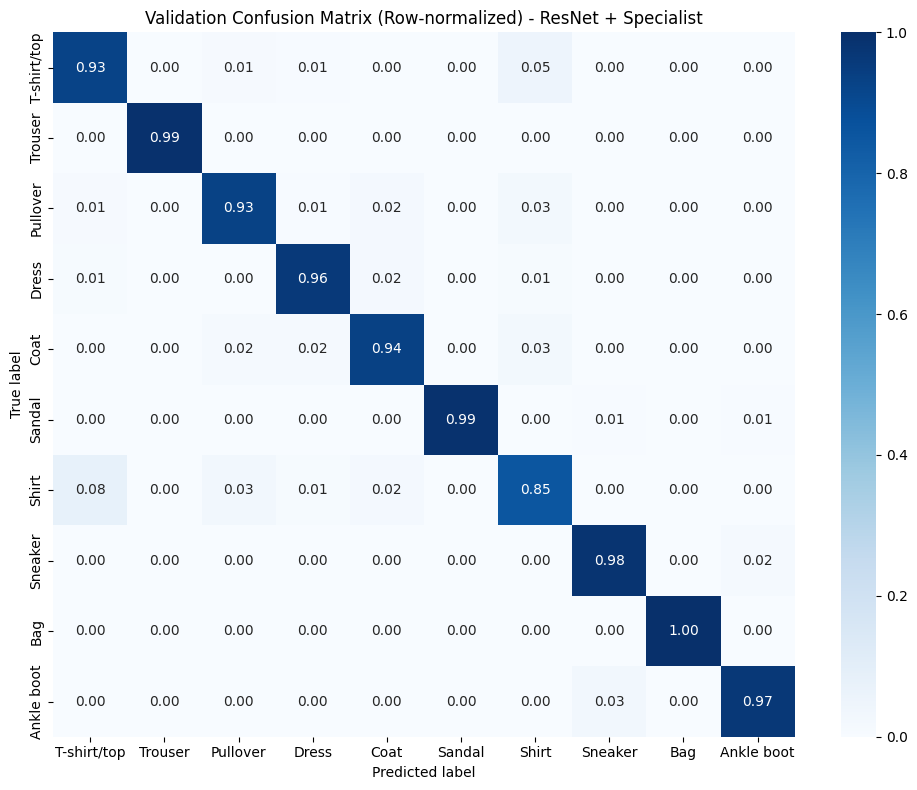

              precision    recall  f1-score   support

 T-shirt/top     0.8982    0.9267    0.9122       600
     Trouser     1.0000    0.9950    0.9975       600
    Pullover     0.9348    0.9317    0.9332       600
       Dress     0.9585    0.9617    0.9601       600
        Coat     0.9336    0.9367    0.9351       600
      Sandal     1.0000    0.9883    0.9941       600
       Shirt     0.8810    0.8517    0.8661       600
     Sneaker     0.9640    0.9817    0.9727       600
         Bag     0.9950    1.0000    0.9975       600
  Ankle boot     0.9765    0.9683    0.9724       600

    accuracy                         0.9542      6000
   macro avg     0.9542    0.9542    0.9541      6000
weighted avg     0.9542    0.9542    0.9541      6000



In [11]:
# Confusion matrix + per-class report
cm = confusion_matrix(y_val, val_pred)
cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title('Validation Confusion Matrix (Row-normalized) - ResNet + Specialist')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()


print(classification_report(y_val, val_pred, target_names=CLASS_NAMES, digits=4))

In [12]:
# Submission — Kaggle reads output from /kaggle/working/
test_pred = np.argmax(test_probs, axis=1)
submission = sample_sub.copy()
submission['label'] = test_pred

submission_path = '/kaggle/working/submission.csv'
submission.to_csv(submission_path, index=False)
np.save('/kaggle/working/test_probs_resnet_specialist.npy', test_probs)

print('Saved submission:        ', submission_path)
print('Saved test probabilities:', '/kaggle/working/test_probs_resnet_specialist.npy')
submission.head()


Saved submission:         /kaggle/working/submission.csv
Saved test probabilities: /kaggle/working/test_probs_resnet_specialist.npy


,imageID,label
0,0,0
1,1,1
2,2,2
3,3,2
4,4,3
